# Data Processing and Comparative Analysis of Signal Infinite Cascade (SIC) for ON-OFF Stimuli

In [1]:
import sys
import os
import csv
import glob
import numpy as np
import pandas as pd
import torch
import re
from tqdm import tqdm
from dtaidistance import dtw
import scipy.stats as stats

# =====================================================
# environment and imports
# =====================================================
sys.path.append(os.path.abspath('../util'))
from SIC import SICModelTorch

os.environ["CUDA_VISIBLE_DEVICES"] = "0"

# =====================================================
# paths
# =====================================================
MASTER_OUT_DIR = "../results/Compare/"
TEMP_NPZ_OUT = os.path.join(MASTER_OUT_DIR, "temp_raw_responses")

METRICS_OUT_DIR = os.path.join(MASTER_OUT_DIR, "evaluation_metrics_step")

MASK_CSV_FILE = '../refer/onoff-mask.csv'
EXP_CSV_FILE = '../refer/EXP.csv'
DMN_CSV_FILE = '../refer/DMN_normalized.csv'
VISUAL_NEURON_FILE = '../data/visual_neuron_types.txt'

target_neurons = ["C3", "Mi1", "Mi4", "Mi9", "T2", "T3", "Tm1", "Tm2", "Tm3", "Tm9", "CT1"]

pad_steps = 50
t_step_model = 10


In [2]:
# =====================================================
# helper functions
# =====================================================
def parse_neuron_name(col_name):
    match = re.search(r'\(([^-\s)]+)', col_name)
    return match.group(1).strip() if match else col_name.strip()


def read_target_neuron_ids(neuron_type, filename=VISUAL_NEURON_FILE):
    ids = []
    with open(filename, 'r') as f:
        for row in csv.DictReader(f):
            if row['type'].strip().lower() == neuron_type.lower():
                try:
                    ids.append(int(row['root_id']))
                except:
                    continue
    return ids


def get_valid_stimulus(stim_series):
    
    last_valid = stim_series.last_valid_index()

    if last_valid is None:
        return None

    stim_1d = stim_series.loc[:last_valid].to_numpy(dtype=np.float32)

    return stim_1d


# =====================================================
# Phase 1: stimulus simulation
# =====================================================
print("\nPHASE 1: Stimulus Generation")

mask_df = pd.read_csv(MASK_CSV_FILE)
stim_cols = [c for c in mask_df.columns if c.strip() != 'Time (s)']

model = SICModelTorch(
    output_dir=TEMP_NPZ_OUT,
    t_step=t_step_model,
    rate=100,
    device=torch.device("cuda:0")
)

for col in stim_cols:

    neuron_type = parse_neuron_name(col)

    if not any(neuron_type.lower() == t.lower() for t in target_neurons):
        continue

    show_ids = list(set(read_target_neuron_ids(neuron_type)))

    if len(show_ids) == 0:
        continue

    weights = model.load_weights(show_ids, normalize=False)

    stim_1d = get_valid_stimulus(mask_df[col])

    if stim_1d is None or len(stim_1d) == 0:
        print(f"[SKIP] {col} | empty stimulus")
        continue

    padded_stim = np.concatenate([
        np.full(pad_steps, stim_1d[0], dtype=np.float32),
        stim_1d
    ])

    stim_3d = np.broadcast_to(
        padded_stim[None, None, :],
        (41, 82, len(padded_stim))
    ).copy()

    model.calculate_response_baseline(
        stim_3d,
        weights,
        baseline_steps=pad_steps,
        responce_threshold=0,
        stim_name=col,
        downsample=False
    )

    print(
        f"[DONE] {col} | type={neuron_type} | "
        f"stim_len={len(stim_1d)} | padded_len={len(padded_stim)}"
    )


PHASE 1: Stimulus Generation
Using device: cuda:0
[DONE] Fig3A(Mi9-On) | type=Mi9 | stim_len=801 | padded_len=851
[DONE] Fig3A(Tm3-On) | type=Tm3 | stim_len=801 | padded_len=851
[DONE] Fig3A(Mi1-On) | type=Mi1 | stim_len=801 | padded_len=851
[DONE] Fig3A(Mi4-On) | type=Mi4 | stim_len=801 | padded_len=851
[DONE] Fig3A(C3-On) | type=C3 | stim_len=801 | padded_len=851
[DONE] Fig3A(Mi9-Off) | type=Mi9 | stim_len=801 | padded_len=851
[DONE] Fig3A(Tm3-Off) | type=Tm3 | stim_len=801 | padded_len=851
[DONE] Fig3A(Mi1-Off) | type=Mi1 | stim_len=801 | padded_len=851
[DONE] Fig3A(Mi4-Off) | type=Mi4 | stim_len=801 | padded_len=851
[DONE] Fig3A(C3-Off) | type=C3 | stim_len=801 | padded_len=851
[DONE] Fig2A(Tm3-On-1) | type=Tm3 | stim_len=486 | padded_len=536
[DONE] Fig2A(Mi1-On-1) | type=Mi1 | stim_len=486 | padded_len=536
[DONE] Fig2A(Tm3-On-2) | type=Tm3 | stim_len=486 | padded_len=536
[DONE] Fig2A(Mi1-On-2) | type=Mi1 | stim_len=486 | padded_len=536
[DONE] Fig2A(Tm3-On-3) | type=Tm3 | stim_len

In [3]:
import os
import glob
import numpy as np
import pandas as pd
from dtaidistance import dtw


# =====================================================
# Fixed output column order
# =====================================================
LABEL_ORDER = [
    "Fig4a(T3-both)",
    "Fig4a(T2-both)",
    "Fig3A(Mi4-Off)",
    "Fig3A(Mi4-On)",
    "Fig3c(Tm9-Off)Direct",
    "Fig4b(Tm3-off)",
    "Fig2A(Tm3-On-3)",
    "Fig2A(Tm3-On-1)",
    "Fig3A(Tm3-Off)",
    "Fig3A(Tm3-On)",
    "Fig2A(Tm3-On-2)",
    "Fig3A(C3-On)",
    "Fig3A(C3-Off)",
    "Fig2B(Tm1-Off-3)",
    "Fig2B(Tm1-Off-2)",
    "Fig2B(Tm1-Off-1)",
    "Fig4b(Tm1-off)",
    "Fig2A(Mi1-On-1)",
    "Fig2A(Mi1-On-2)",
    "Fig3A(Mi1-On)",
    "Fig3A(Mi1-Off)",
    "Fig2A(Mi1-On-3)",
    "Fig3b(Mi1-on)",
    "Fig2B(Tm2-Off-1)",
    "Fig4b(Tm2-off)",
    "Fig2B(Tm2-Off-2)",
    "Fig2B(Tm2-Off-3)",
    "Fig3A(Mi9-Off)",
    "Fig3A(Mi9-On)",
]


def load_npz_mean_series(npz_path, normalize=True):
    """
    Load neuron population responses from NPZ and compute mean time series.

    Output:
        1D time series (optionally normalized)
    """
    data = np.load(npz_path, allow_pickle=True)
    resps = data["responses"]

    arr = np.stack(resps, axis=0)
    mean_resp = np.mean(arr, axis=0)

    if normalize:
        min_v = mean_resp.min()
        max_v = mean_resp.max()

        if max_v > min_v:
            mean_resp = (mean_resp - min_v) / (max_v - min_v)
        else:
            mean_resp = np.zeros_like(mean_resp)

    return mean_resp


def get_metrics(target_array, pred_array):
    """
    target_array: experimental signal
    pred_array: model signal

    Returns:
        best_lag, mcc, mse, dtw
    """
    t = np.asarray(target_array, dtype=float).flatten()
    e = np.asarray(pred_array, dtype=float).flatten()

    if len(t) < 2 or len(e) < 2:
        return None, None, None, None

    t_c = t - np.mean(t)
    e_c = e - np.mean(e)

    denom = np.sqrt(np.sum(t_c ** 2) * np.sum(e_c ** 2))
    if denom == 0:
        return None, None, None, None

    corr = np.correlate(e_c, t_c, mode="full")
    cc = corr / denom

    lags = np.arange(-len(t) + 1, len(e))

    best_idx = np.argmax(cc)
    best_lag = lags[best_idx]
    mcc = cc[best_idx]

    # MSE after alignment
    if best_lag > 0:
        e_aligned = e[best_lag:]
        t_aligned = t[:len(e_aligned)]
    elif best_lag < 0:
        t_aligned = t[-best_lag:]
        e_aligned = e[:len(t_aligned)]
    else:
        e_aligned = e
        t_aligned = t

    if len(t_aligned) < 2:
        return best_lag, None, None, None

    mse = np.mean((t_aligned - e_aligned) ** 2)

    # DTW without alignment
    dtw_val = dtw.distance(e, t) / len(t)

    return abs(best_lag), mcc, mse, dtw_val


# =====================================================
# Phase 2: evaluation
# =====================================================
print("\nPHASE 2: Metrics Calculation")

npz_files = glob.glob(os.path.join(TEMP_NPZ_OUT, "**/*.npz"), recursive=True)

exp_df = pd.read_csv(EXP_CSV_FILE)
dmn_df = pd.read_csv(DMN_CSV_FILE)

exp_map = {c.lower().strip(): c for c in exp_df.columns}
dmn_map = {c.lower().strip(): c for c in dmn_df.columns}

npz_map = {
    os.path.basename(f).replace(".npz", "").lower().strip(): f
    for f in npz_files
}

metrics_table = pd.DataFrame(
    index=[
        "SIC_Best Lag",
        "SIC_MCC",
        "SIC_MSE",
        "SIC_DTW",
        "DMN_Best Lag",
        "DMN_MCC",
        "DMN_MSE",
        "DMN_DTW",
    ],
    columns=LABEL_ORDER,
    dtype=float,
)

metrics_summary = {
    "SIC": {"lag": [], "mcc": [], "mse": [], "dtw": []},
    "DMN": {"lag": [], "mcc": [], "mse": [], "dtw": []},
}

for label in LABEL_ORDER:
    l_low = label.lower().strip()

    if l_low not in npz_map:
        print(f"[Skip] NPZ not found: {label}")
        continue

    if l_low not in exp_map:
        print(f"[Skip] Experimental column not found: {label}")
        continue

    if l_low not in dmn_map:
        print(f"[Skip] DMN column not found: {label}")
        continue

    f = npz_map[l_low]

    exp_series = pd.to_numeric(
        exp_df[exp_map[l_low]], errors="coerce"
    ).dropna().values

    dmn_series = pd.to_numeric(
        dmn_df[dmn_map[l_low]], errors="coerce"
    ).dropna().values

    sic_series = load_npz_mean_series(f)

    mlen = min(len(sic_series), len(exp_series), len(dmn_series))

    sic_series = sic_series[:mlen]
    exp_series = exp_series[:mlen]
    dmn_series = dmn_series[:mlen]

    s_l, s_mcc, s_mse, s_dtw = get_metrics(exp_series, sic_series)
    d_l, d_mcc, d_mse, d_dtw = get_metrics(exp_series, dmn_series)

    metrics_table.loc["SIC_Best Lag", label] = s_l
    metrics_table.loc["SIC_MCC", label] = s_mcc
    metrics_table.loc["SIC_MSE", label] = s_mse
    metrics_table.loc["SIC_DTW", label] = s_dtw

    metrics_table.loc["DMN_Best Lag", label] = d_l
    metrics_table.loc["DMN_MCC", label] = d_mcc
    metrics_table.loc["DMN_MSE", label] = d_mse
    metrics_table.loc["DMN_DTW", label] = d_dtw

    metrics_summary["SIC"]["lag"].append(s_l)
    metrics_summary["SIC"]["mcc"].append(s_mcc)
    metrics_summary["SIC"]["mse"].append(s_mse)
    metrics_summary["SIC"]["dtw"].append(s_dtw)

    metrics_summary["DMN"]["lag"].append(d_l)
    metrics_summary["DMN"]["mcc"].append(d_mcc)
    metrics_summary["DMN"]["mse"].append(d_mse)
    metrics_summary["DMN"]["dtw"].append(d_dtw)

    print(
        f"{label}: "
        f"SIC(lag={s_l}, mcc={s_mcc:.4f}, mse={s_mse:.4f}, dtw={s_dtw:.4f}) | "
        f"DMN(lag={d_l}, mcc={d_mcc:.4f}, mse={d_mse:.4f}, dtw={d_dtw:.4f})"
    )


# =====================================================
# Save wide-format metrics table
# =====================================================
os.makedirs(METRICS_OUT_DIR, exist_ok=True)

metrics_out_path = os.path.join(
    METRICS_OUT_DIR,
    "SIC_DMN_metrics_wide.csv"
)

metrics_table.to_csv(metrics_out_path, index=True)

print(f"\nSaved wide-format metrics table to:")
print(metrics_out_path)


# =====================================================
# summary statistics
# =====================================================
print("\n===== OVERALL SUMMARY =====")

for model in ["SIC", "DMN"]:
    print(f"\n{model}:")

    for k in ["lag", "mcc", "mse", "dtw"]:
        arr = np.array(metrics_summary[model][k], dtype=float)
        arr = arr[~np.isnan(arr)]

        if len(arr) == 0:
            continue

        mean_val = np.mean(arr)
        std_val = np.std(arr)
        n = len(arr)

        print(f"  {k}: {mean_val:.4f} ± {std_val:.4f} (n={n})")

print("\nProcessing complete.")


PHASE 2: Metrics Calculation
Fig4a(T3-both): SIC(lag=0, mcc=0.8050, mse=0.0375, dtw=0.0070) | DMN(lag=0, mcc=0.6762, mse=0.1217, dtw=0.0049)
Fig4a(T2-both): SIC(lag=10, mcc=0.6925, mse=0.0391, dtw=0.0054) | DMN(lag=0, mcc=0.5455, mse=0.0803, dtw=0.0037)
Fig3A(Mi4-Off): SIC(lag=42, mcc=0.8691, mse=0.0849, dtw=0.0097) | DMN(lag=31, mcc=0.9261, mse=0.0319, dtw=0.0051)
Fig3A(Mi4-On): SIC(lag=7, mcc=0.9608, mse=0.0122, dtw=0.0024) | DMN(lag=4, mcc=0.9320, mse=0.0611, dtw=0.0082)
Fig3c(Tm9-Off)Direct: SIC(lag=17, mcc=0.9558, mse=0.0103, dtw=0.0053) | DMN(lag=33, mcc=0.8244, mse=0.0714, dtw=0.0075)
Fig4b(Tm3-off): SIC(lag=3, mcc=0.9694, mse=0.0032, dtw=0.0065) | DMN(lag=2, mcc=0.9201, mse=0.0190, dtw=0.0140)
Fig2A(Tm3-On-3): SIC(lag=3, mcc=0.9342, mse=0.0071, dtw=0.0010) | DMN(lag=2, mcc=0.9092, mse=0.0120, dtw=0.0030)
Fig2A(Tm3-On-1): SIC(lag=5, mcc=0.7980, mse=0.0117, dtw=0.0039) | DMN(lag=4, mcc=0.7827, mse=0.0133, dtw=0.0042)
Fig3A(Tm3-Off): SIC(lag=23, mcc=0.8949, mse=0.1334, dtw=0.0113

In [4]:
import os
import glob
import numpy as np
import pandas as pd


# =====================================================
# paths
# =====================================================
MASTER_OUT_DIR = "../results/Compare/"
TEMP_NPZ_OUT = os.path.join(MASTER_OUT_DIR, "temp_raw_responses")
METRICS_OUT_DIR = os.path.join(MASTER_OUT_DIR, "evaluation_metrics_step_100")

MASK_CSV_FILE = "../refer/onoff-mask.csv"


# =====================================================
# Fixed output order
# =====================================================
LABEL_ORDER = [
    "Fig3A(Mi9-On)",
    "Fig3A(Tm3-On)",
    "Fig3A(Mi1-On)",
    "Fig3A(Mi4-On)",
    "Fig3A(C3-On)",

    "Fig3A(Mi9-Off)",
    "Fig3A(Tm3-Off)",
    "Fig3A(Mi1-Off)",
    "Fig3A(Mi4-Off)",
    "Fig3A(C3-Off)",

    "Fig2A(Tm3-On-1)",
    "Fig2A(Mi1-On-1)",
    "Fig2A(Tm3-On-2)",
    "Fig2A(Mi1-On-2)",
    "Fig2A(Tm3-On-3)",
    "Fig2A(Mi1-On-3)",

    "Fig2B(Tm1-Off-1)",
    "Fig2B(Tm2-Off-1)",
    "Fig2B(Tm1-Off-2)",
    "Fig2B(Tm2-Off-2)",
    "Fig2B(Tm1-Off-3)",
    "Fig2B(Tm2-Off-3)",

    "Fig3c(Tm9-Off)Direct",
    "Fig3b(Mi1-on)",

    "Fig4b(Tm1-off)",
    "Fig4b(Tm2-off)",
    "Fig4b(Tm3-off)",

    "Fig4a(T2-both)",
    "Fig4a(T3-both)"
]

# =====================================================
# Load SIC mean response
# =====================================================
def load_npz_mean_series(npz_path, normalize=True):
    data = np.load(npz_path, allow_pickle=True)

    responses = data["responses"]
    arr = np.stack(responses, axis=0)

    mean_resp = np.mean(arr, axis=0)

    if normalize:
        min_v = mean_resp.min()
        max_v = mean_resp.max()

        if max_v > min_v:
            mean_resp = (mean_resp - min_v) / (max_v - min_v)
        else:
            mean_resp = np.zeros_like(mean_resp)

    return mean_resp


# =====================================================
# Build NPZ map
# =====================================================
npz_files = glob.glob(
    os.path.join(TEMP_NPZ_OUT, "**/*.npz"),
    recursive=True
)

npz_map = {
    os.path.basename(f).replace(".npz", "").lower().strip(): f
    for f in npz_files
}


# =====================================================
# Read mask csv from onoff-mask.csv
# =====================================================
mask_df = pd.read_csv(MASK_CSV_FILE)

mask_map = {
    c.lower().strip(): c
    for c in mask_df.columns
    if c.strip() != "Time (s)"
}


# =====================================================
# Save mask + SIC mean response
# Output columns:
# Stimuli, Value, Stimuli, Value, ...
# =====================================================
output_cols = []

print("\n===== Saving Stimuli + Value pairs =====\n")

for label in LABEL_ORDER:

    key = label.lower().strip()

    if key not in npz_map:
        print(f"[Skip] NPZ not found: {label}")
        continue

    if key not in mask_map:
        print(f"[Skip] Mask column not found in onoff-mask.csv: {label}")
        continue

    sic_series = load_npz_mean_series(
        npz_map[key],
        normalize=True
    )

    mask_series = pd.to_numeric(
        mask_df[mask_map[key]],
        errors="coerce"
    ).fillna(0).values.astype(float)

    mlen = min(len(mask_series), len(sic_series))

    mask_series = mask_series[:mlen]
    sic_series = sic_series[:mlen]

    # Stimuli, Value
    output_cols.append(pd.Series(mask_series, name="Stimuli"))
    output_cols.append(pd.Series(sic_series, name="SIC_Value"))

    print(
        f"[DONE] {label:28s} | "
        f"stimuli_len={len(mask_series):5d} | "
        f"value_len={len(sic_series):5d} | "
        f"saved_len={mlen:5d}"
    )


# =====================================================
# Save CSV
# =====================================================
os.makedirs(METRICS_OUT_DIR, exist_ok=True)

if len(output_cols) == 0:
    raise RuntimeError(
        "No valid data found. Please check NPZ files and mask columns."
    )

output_df = pd.concat(output_cols, axis=1)

output_df = output_df.round(2)

out_csv = os.path.join(
    METRICS_OUT_DIR,
    "SIC_mask_mean_response_traces.csv"
)

output_df.to_csv(
    out_csv,
    index=False,
    float_format="%.2f"
)

print("\nSaved:")
print(out_csv)

print("\nOutput shape:")
print(output_df.shape)

print("\nFirst few rows:")
print(output_df.head())


===== Saving Stimuli + Value pairs =====

[DONE] Fig3A(Mi9-On)                | stimuli_len=  801 | value_len=  801 | saved_len=  801
[DONE] Fig3A(Tm3-On)                | stimuli_len=  801 | value_len=  801 | saved_len=  801
[DONE] Fig3A(Mi1-On)                | stimuli_len=  801 | value_len=  801 | saved_len=  801
[DONE] Fig3A(Mi4-On)                | stimuli_len=  801 | value_len=  801 | saved_len=  801
[DONE] Fig3A(C3-On)                 | stimuli_len=  801 | value_len=  801 | saved_len=  801
[DONE] Fig3A(Mi9-Off)               | stimuli_len=  801 | value_len=  801 | saved_len=  801
[DONE] Fig3A(Tm3-Off)               | stimuli_len=  801 | value_len=  801 | saved_len=  801
[DONE] Fig3A(Mi1-Off)               | stimuli_len=  801 | value_len=  801 | saved_len=  801
[DONE] Fig3A(Mi4-Off)               | stimuli_len=  801 | value_len=  801 | saved_len=  801
[DONE] Fig3A(C3-Off)                | stimuli_len=  801 | value_len=  801 | saved_len=  801
[DONE] Fig2A(Tm3-On-1)              |

Metric	SIC mean	SIC SEM	DMN mean	DMN SEM
lag	118.2759	22.5803	346.2069	191.5753
mcc	0.8381	0.0217	0.7432	0.0365
mse	0.0549	0.0095	0.0789	0.0142
dtw	0.0078	0.0009	0.0114	0.0013


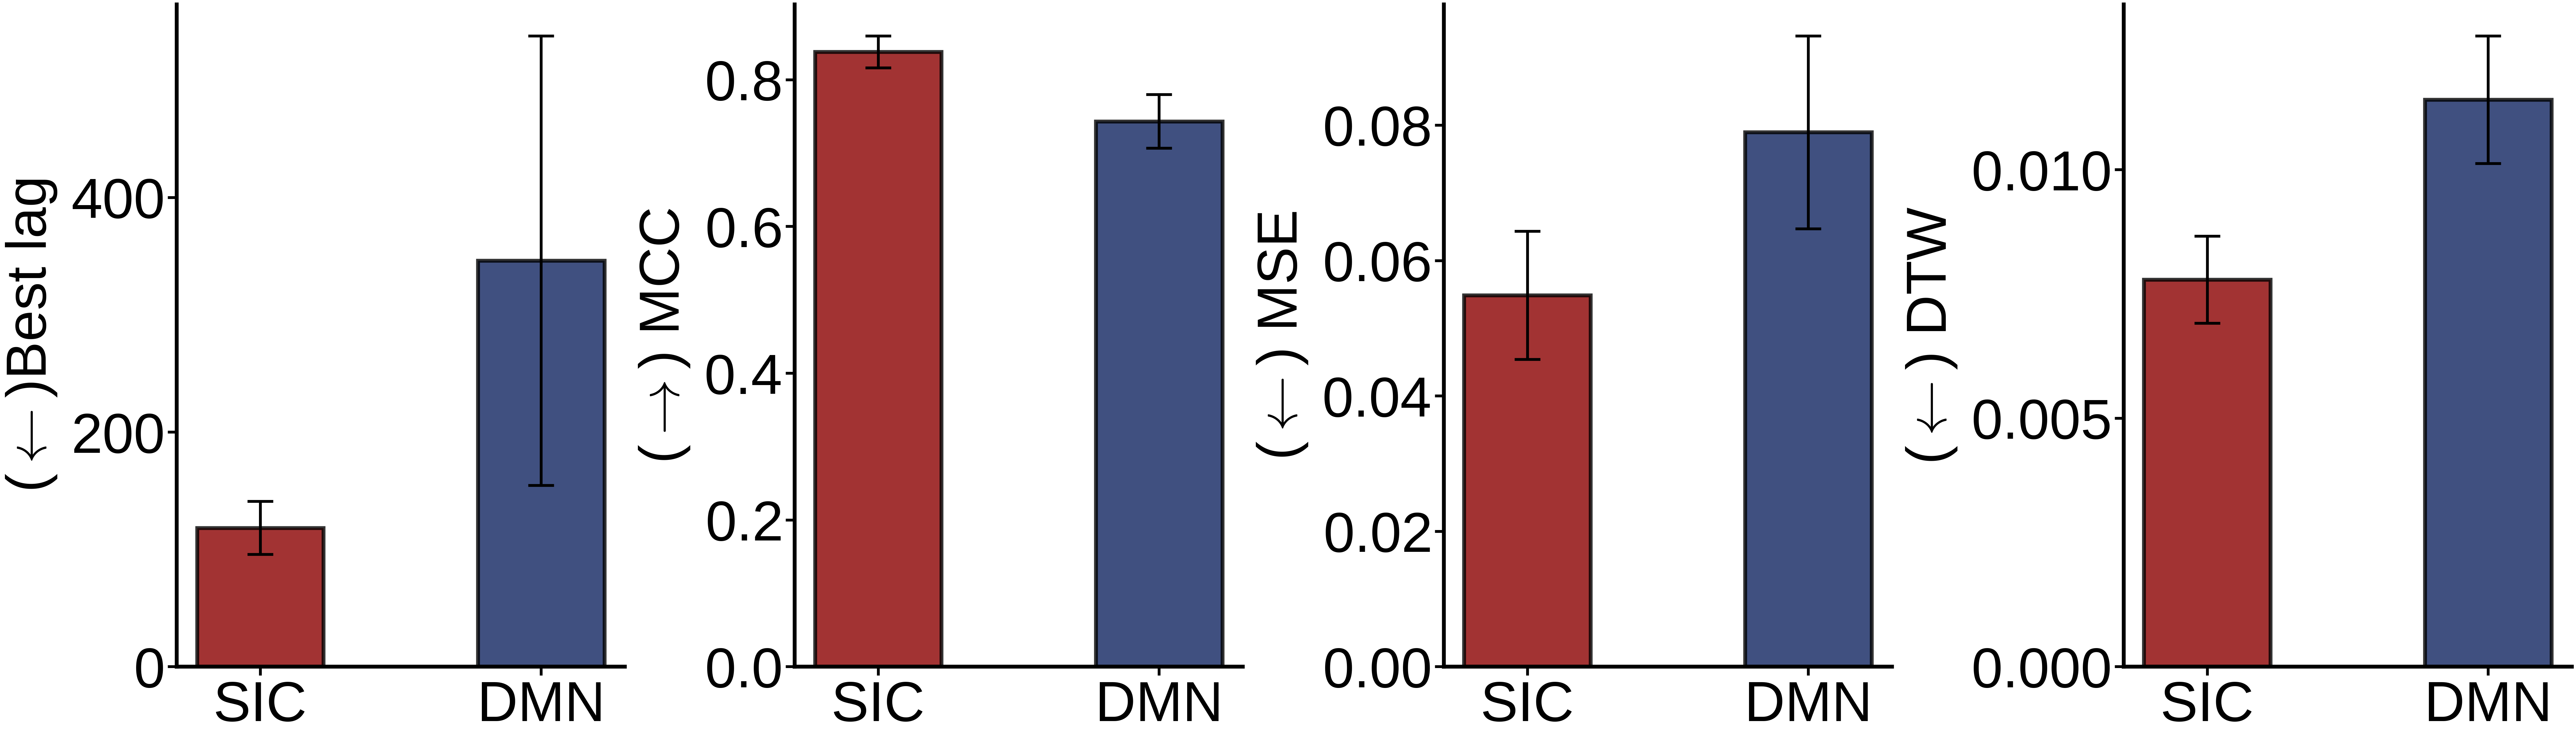

Saved: ../results/Figure2/b.png


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots

# ==================== Style ====================
plt.style.use(['science', 'nature', 'no-latex'])

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Liberation Sans"],

    "font.size": 44,
    "axes.labelsize": 44,
    "axes.titlesize": 44,
    "legend.fontsize": 44,
    "xtick.labelsize": 44,
    "ytick.labelsize": 44,

    "axes.linewidth": 3,
    "figure.dpi": 300,
    "savefig.dpi": 600,

    "xtick.top": False,
    "ytick.right": False,
    "xtick.minor.top": False,
    "ytick.minor.right": False,
    "xtick.minor.visible": False,
    "ytick.minor.visible": False,
})

# ==================== Colors ====================
COLOR_SIC = "#8B0000"
COLOR_DMN = "#102461"

model_colors = {
    "SIC": COLOR_SIC,
    "DMN": COLOR_DMN,
}

# ==================== Helper ====================
def clean(arr):
    arr = np.asarray(arr, dtype=float)
    return arr[~np.isnan(arr)]


def stylize_axis(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


    ax.minorticks_off()

    ax.tick_params(
        axis="both",
        which="both",
        top=False,
        right=False,
        direction="out",
        width=2.2,
        length=7
    )

    ax.xaxis.set_ticks_position("bottom")
    ax.yaxis.set_ticks_position("left")
    ax.grid(False)


# ==================== Metrics ====================
metric_names = ["lag", "mcc", "mse", "dtw"]

fig, axes = plt.subplots(
    1,
    4,
    figsize=(28, 8),
    constrained_layout=True
)

axes = axes.flatten()

print(
    "Metric\t"
    "SIC mean\tSIC SEM\t"
    "DMN mean\tDMN SEM"
)

for i, name in enumerate(metric_names):

    sic_data = clean(metrics_summary["SIC"][name])
    dmn_data = clean(metrics_summary["DMN"][name])

    if name == "lag":
        sic_data = np.abs(sic_data * 10)
        dmn_data = np.abs(dmn_data * 10)

    sic_mean = np.mean(sic_data)
    dmn_mean = np.mean(dmn_data)

    sic_sem = np.std(sic_data, ddof=1) / np.sqrt(len(sic_data))
    dmn_sem = np.std(dmn_data, ddof=1) / np.sqrt(len(dmn_data))

    print(
        f"{name}\t"
        f"{sic_mean:.4f}\t{sic_sem:.4f}\t"
        f"{dmn_mean:.4f}\t{dmn_sem:.4f}"
    )

    x = np.array([0, 1])

    means = np.array([sic_mean, dmn_mean])
    errors = np.array([sic_sem, dmn_sem])

    bar_colors = [
        model_colors["SIC"],
        model_colors["DMN"]
    ]

    axes[i].bar(
        x,
        means,
        yerr=errors,
        width=0.45,
        capsize=10,
        color=bar_colors,
        alpha=0.8,
        edgecolor="black",
        linewidth=3,
        error_kw=dict(
            ecolor="black",
            elinewidth=2.2,
            capthick=2.2
        )
    )

    axes[i].set_xticks(x)
    axes[i].set_xticklabels(["SIC", "DMN"])

    if name == "lag":
        ylabel = r"($\leftarrow$)Best lag"
    elif name == "mcc":
        ylabel = r"($\rightarrow$) MCC"
    elif name == "mse":
        ylabel = r"($\leftarrow$) MSE"
    else:
        ylabel = r"($\leftarrow$) DTW"

    axes[i].set_ylabel(
        ylabel,
        labelpad=10
    )

    stylize_axis(axes[i])

out_png = "../results/Figure2/b.png"

plt.savefig(
    out_png,
    dpi=600,
    bbox_inches="tight"
)

plt.show()

print(f"Saved: {out_png}")